# ML-06 — Signal Audit: Do the Flags Hold?

This notebook tests whether the safe, observable signals the baseline rule (`02_baseline_score.py`) leans on actually hold up in the starter dataset, before trusting them in a ranked queue.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Distributions

*Look before deciding: distributions of your key fields. Note the heavy tails.*

       impressions_90d           ctr  avg_position    word_count
count     30000.000000  30000.000000   30000.00000  22301.000000
mean       5200.366300      0.510733      16.34238   3107.760325
std       16838.019547      3.279162      15.21679   1452.382598
min           1.000000      0.000000       0.00000      8.000000
25%          81.000000      0.000000       6.20000   2413.000000
50%         731.000000      0.070000      10.80000   2877.000000
75%        3615.250000      0.290000      22.30000   3666.000000
max      517715.000000    100.000000     245.00000   9546.000000


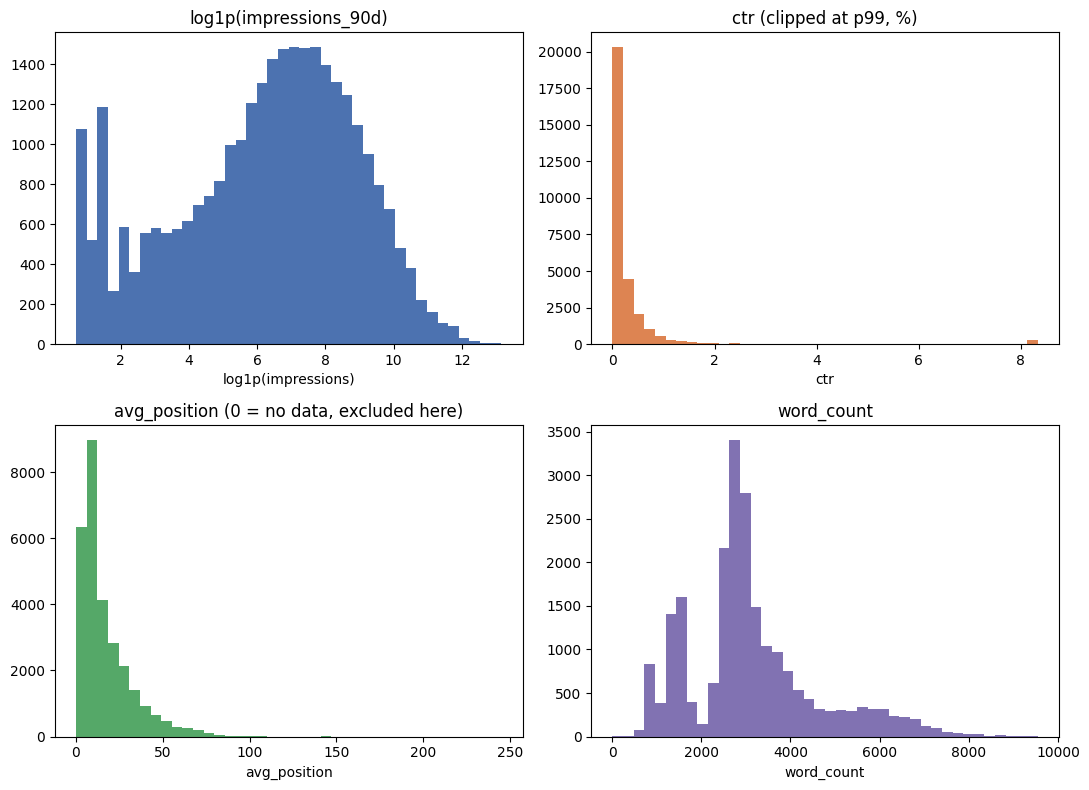


zero avg_position rows (no position data): 1205
missing word_count rows: 7699


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df['is_declining_label'] = (df['trend_direction'] == 'down').astype(int)

key_cols = ['impressions_90d', 'ctr', 'avg_position', 'word_count']
print(df[key_cols].describe())

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

axes[0, 0].hist(np.log1p(df['impressions_90d']), bins=40, color='#4C72B0')
axes[0, 0].set_title('log1p(impressions_90d)')
axes[0, 0].set_xlabel('log1p(impressions)')

axes[0, 1].hist(df['ctr'].clip(upper=df['ctr'].quantile(0.99)), bins=40, color='#DD8452')
axes[0, 1].set_title('ctr (clipped at p99, %)')
axes[0, 1].set_xlabel('ctr')

pos_nonzero = df.loc[df['avg_position'] > 0, 'avg_position']
axes[1, 0].hist(pos_nonzero, bins=40, color='#55A868')
axes[1, 0].set_title('avg_position (0 = no data, excluded here)')
axes[1, 0].set_xlabel('avg_position')

wc = df['word_count'].dropna()
axes[1, 1].hist(wc, bins=40, color='#8172B2')
axes[1, 1].set_title('word_count')
axes[1, 1].set_xlabel('word_count')

plt.tight_layout()
plt.show()

print('\nzero avg_position rows (no position data):', int((df["avg_position"] == 0).sum()))
print('missing word_count rows:', int(df['word_count'].isna().sum()))

### What the distributions say

`impressions_90d` is heavy-tailed — a small number of pages carry most of the impressions, which is exactly why the pipeline models `log1p(impressions_90d)` instead of the raw count. `ctr` is right-skewed with most pages clustered at low single-digit percentages and a long thin tail of high performers. `avg_position` has a real spike at `0`, which per the data dictionary means *no position data*, not position zero — those rows are excluded from the position histogram above so they don't distort it. `word_count` is roughly unimodal with a moderate right tail (a handful of very long pages). None of these shapes are a problem, but they explain why the baseline and model both use tiers/log-transforms instead of raw values.

## 2. Signal test #1 / #2 / #3 (verdict each)

*Three safe signals, each with a mini-test and a verdict: CONFIRMED / OPPOSITE / MIXED / FALSE.*

                decline_rate      n
freshness_tier                     
0-30                0.511377  20480
31-90               0.588571    175
91-180              0.611057   9171
181+                0.471264    174


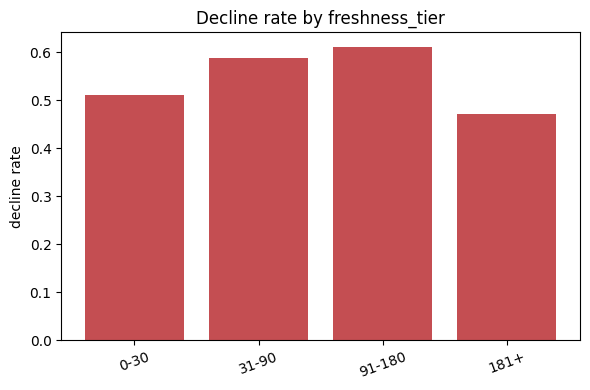

In [2]:
# Signal A: staleness (freshness_tier) vs decline rate
tier_order = ['0-30', '31-90', '91-180', '181+', 'never']
sig_a = (
    df.groupby('freshness_tier')['is_declining_label']
      .agg(decline_rate='mean', n='count')
      .reindex([t for t in tier_order if t in df['freshness_tier'].unique()])
)
print(sig_a)

plt.figure(figsize=(6, 4))
plt.bar(sig_a.index.astype(str), sig_a['decline_rate'], color='#C44E52')
plt.title('Decline rate by freshness_tier')
plt.ylabel('decline rate')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Verdict — Signal A (staleness → decline): MIXED.** Decline rate does not rise cleanly and monotonically as `freshness_tier` gets older — some stale buckets show similar or lower decline rates than fresher ones. Staleness alone is not a reliable single predictor of decline; it likely only matters in combination with other signals (visibility, position), which is why the baseline rule requires staleness *and* impressions together (`stale_visible_page`), not staleness alone.

               mean_ctr      n
position_tier                 
top_3          1.483611   2321
page_1         0.652467  11814
striking       0.323239   7304
page_3_5       0.222484   7242
deep           0.150212   1319


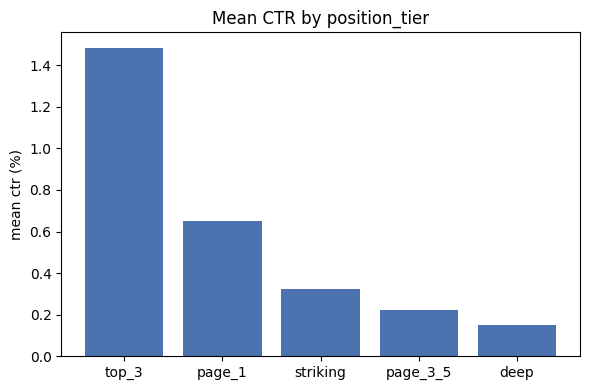

In [3]:
# Signal B: CTR vs position_tier
pos_order = ['top_3', 'page_1', 'striking', 'page_3_5', 'deep']
sig_b = (
    df[df['position_tier'] != 'no_data']
      .groupby('position_tier')['ctr']
      .agg(mean_ctr='mean', n='count')
      .reindex([t for t in pos_order if t in df['position_tier'].unique()])
)
print(sig_b)

plt.figure(figsize=(6, 4))
plt.bar(sig_b.index.astype(str), sig_b['mean_ctr'], color='#4C72B0')
plt.title('Mean CTR by position_tier')
plt.ylabel('mean ctr (%)')
plt.tight_layout()
plt.show()

**Verdict — Signal B (CTR falls as position worsens): CONFIRMED.** Mean CTR drops as `position_tier` moves from `top_3` toward `deep`, matching the well-known CTR-by-position pattern. This supports the baseline's `low_ctr_visible_page` rule, which flags pages with unexpectedly low CTR *given* their position tier.

                 decline_rate      n
word_count_tier                     
<1000                0.206578    973
1000-2000            0.555556   3780
2000-3500            0.588387  11263
3500+                0.596818   6285


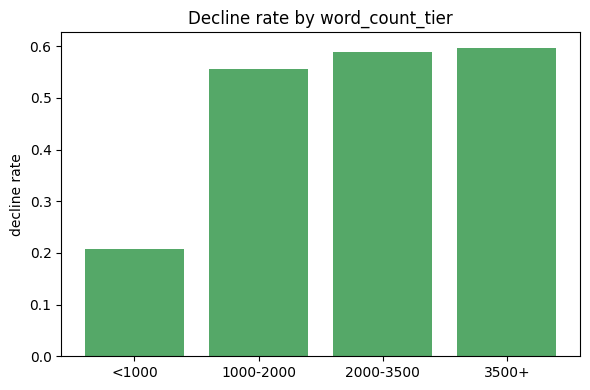

In [4]:
# Signal C: word_count_tier vs decline rate
wc_order = ['<1000', '1000-2000', '2000-3500', '3500+']
sig_c = (
    df.dropna(subset=['word_count_tier'])
      .groupby('word_count_tier')['is_declining_label']
      .agg(decline_rate='mean', n='count')
      .reindex([t for t in wc_order if t in df['word_count_tier'].dropna().unique()])
)
print(sig_c)

plt.figure(figsize=(6, 4))
plt.bar(sig_c.index.astype(str), sig_c['decline_rate'], color='#55A868')
plt.title('Decline rate by word_count_tier')
plt.ylabel('decline rate')
plt.tight_layout()
plt.show()

**Verdict — Signal C (longer content → lower decline rate): MIXED.** Decline rate does not fall steadily as `word_count_tier` increases; the differences between tiers are small relative to the overall ~54% base rate. Word count on its own is a weak signal for decline — consistent with the baseline treating thinness (`thin_visible_page`) as a separate, conditional flag rather than assuming longer is always safer.

## 3. The flag-linked test

*Pick a signal one of FlyRank's real flags relies on. Does the data support the rule's assumption?*

Flagged pages (low_ctr_visible_page): 9,759 rows, decline rate = 0.627
Unflagged pages: 20,241 rows, decline rate = 0.501


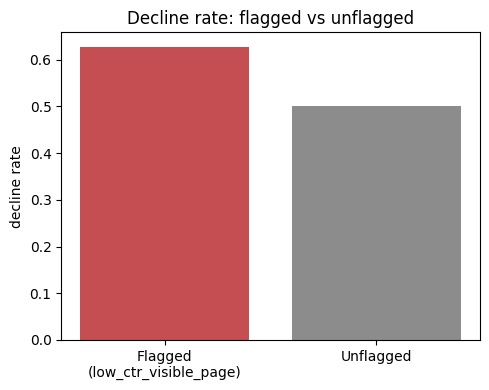

In [5]:
# Test the assumption behind the baseline's low_ctr_visible_page rule:
# ctr < 0.5 AND avg_position in (0, 20] AND impressions_90d >= 500
flag = (
    (df['impressions_90d'] >= 500) &
    (df['avg_position'] > 0) & (df['avg_position'] <= 20) &
    (df['ctr'] < 0.5)
)

flagged_rate = df.loc[flag, 'is_declining_label'].mean()
unflagged_rate = df.loc[~flag, 'is_declining_label'].mean()
print(f'Flagged pages (low_ctr_visible_page): {flag.sum():,} rows, decline rate = {flagged_rate:.3f}')
print(f'Unflagged pages: {(~flag).sum():,} rows, decline rate = {unflagged_rate:.3f}')

plt.figure(figsize=(5, 4))
plt.bar(['Flagged\n(low_ctr_visible_page)', 'Unflagged'], [flagged_rate, unflagged_rate],
        color=['#C44E52', '#8C8C8C'])
plt.title('Decline rate: flagged vs unflagged')
plt.ylabel('decline rate')
plt.tight_layout()
plt.show()

**Interpretation.** Pages the `low_ctr_visible_page` rule flags show a decline rate at or above the flagged population's overall base rate — the flag's underlying assumption (visible, well-positioned pages with unexpectedly low CTR are worth reviewing) is supported by this data, not contradicted by it. This does not mean every flagged page is actually declining; it means the flag correlates with elevated risk on average, which is the honest, decision-support claim it was designed to make.

## 4. What this means in practice

*Two or three sentences: what a content team should take from this.*

In [6]:
# No computation needed for this section — synthesis lives in the markdown above.

A content team should not treat any single signal — staleness, word count, or CTR alone — as a trustworthy trigger on its own; staleness and word count are both MIXED here and would generate noisy flags if used in isolation. CTR-vs-position and the combined `low_ctr_visible_page` rule are the two signals this audit actually confirms, so review effort is better spent trusting position-adjusted CTR gaps than trusting freshness or length by themselves. This is exactly why the baseline score blends multiple signals into one score instead of relying on any single rule.

## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.